# 事前準備：共通コードの実行
* このノートブックに接続したら，まずは以下の2つの共通コード（コードAとコードB）を実行する
* これらの共通コードを実行しないと，それ以降のコードが実行できないので注意する
* また，コードA，コードB，及びコードC は，ノートブックに接続するたび毎回実行すること（ノートブックに接続中は，何度も実行する必要はない）
* 共通コードの詳細についての説明は割愛する（簡単な説明は[第2回のサンプルノートブック](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook02.ipynb)を参照）

In [ ]:
# コードA：日本語化ライブラリ導入
! pip install japanize-matplotlib | tail -n 1

In [4]:
# コードB：共通事前処理

# B1:余分なワーニングを非表示にする
import warnings
warnings.filterwarnings('ignore')

# 必要ライブラリのimport
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib # matplotlib日本語化対応
import seaborn as sns

# B2:データフレーム表示用関数
from IPython.display import display

# B3:表示オプション調整
np.set_printoptions(suppress = True, precision = 3) #numpyの浮動小数点の表示精度
pd.options.display.float_format = '{:.3f}'.format #pandasでの浮動小数点の表示精度
pd.set_option('display.max_columns', None) #データフレームですべての列データを表示

# B4:グラフのデフォルトフォント指定
plt.rcParams['font.size'] = 14

# 乱数の種
random_seed = 0

In [5]:
# コードC：データのダウンロード
!curl -L -o insect.csv https://raw.githubusercontent.com/yoshida-nu/lecture_public/main/datascience/resources/05/insect.csv
!curl -L -o Survived.csv https://raw.githubusercontent.com/yoshida-nu/lecture_public/main/datascience/resources/05/Survived.csv
!curl -L -o iris.csv https://raw.githubusercontent.com/yoshida-nu/lecture_public/main/datascience/resources/05/iris.csv

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100    220 100    220   0      0    814      0                              0
100    220 100    220   0      0    812      0                              0
100    220 100    220   0      0    810      0                              0
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  33536 100  33536   0      0 153.8k      0                              0
100  33536 100  33536   0      0 153.6k      0                              0
100  33536 100  33536   0      0 153.4k      0                              0
  % Total    % Received % Xferd  Average Speed  Time    Time  

# 目的と到達目標

## 目的
* ロジスティック回帰モデルの学習のしくみを理解する
* アンサンブル学習（バギングとブースティング）のしくみを理解する

## 到達目標
* ロジスティック回帰によるデータ分析を実践できる
* ランダムフォレストによるデータ分析を実践できる
* アダブーストによるデータ分析を実践できる


# ロジスティック回帰

## 2カテゴリ分類の例
* ここで，カテゴリが2個の簡単な分類の例を考える
* 例: 昆虫の重量とメス/オス
  * データ（csvファイル）： insect.csv
  * 説明変数`x` : 重量
  * 目的変数`y`: メス ⇒ 0，オス ⇒ 1

### 実習：データの読み込み
**［実習内容］**
* 以下の「分析手順」と「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，csvファイル「insect.csv」をDataFrameとして読み込んで，変数`df`に代入
* 3行目: `display`関数を使ってデータ（`df`の内容）を表示

In [ ]:
# データの読み込み

display(df)

### 実習：散布図の作成
**［実習内容］**
* 以下の「分析手順」と「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，csvファイル「insect.csv」をDataFrameとして読み込んで，変数`df`に代入
* 3行目: pyplotモジュールの`scatter`関数を使って「重量」と「性別」の散布図を作成
* 4～5行目: `xlabel`関数と`ylabel`関数で，各軸のラベル（タイトル）をそれぞれ「重量」「オス=1 / メス=0」に設定
* 6行目: `show`関数で，それまでに設定した図（国語と数学の散布図）を実行画面に表示

**実行結果：**

  <img src="./fig/exercise_insect_scatter.jpg" width="300">

In [ ]:
# 散布図の作成



plt.ylabel('オス=1 / メス=0')
plt.show()

## ロジスティック回帰モデル 
* 作成した散布図から，重量が0.8～1.2あたりには，オスとメスが混在していることが分かる

  <img src="./fig/example_logistic_scatter.jpg" width="350">

* 下図はで，重量を表す数直線上でオスとメスが区別できるようにデータプロットしている（上図と表現を変えているだけ）

  <img src="./fig/example_insect_line.jpg" width="350">

* この図から，オス/メスを完全に分類できる重量（しきい値）は決められないことがわかる
* 例えば，しきい値を「1」とすると以下のような分類ができる（下図）
  * 重量`x`が「1」未満 ⇒ メス
  * 重量`x`が「1」以上 ⇒ オス

  <img src="./fig/example_insect_line_threshold.jpg" width="350">

* この場合，メスをオス，オスをメスに誤分類することがある
* そこで，あるカテゴリに属するかどうかの確率を導入する
  * 例えば，重量が「0.9」のとき，「確率0.8でメス，確率0.2でオス」などと分類する
* このような分類を実現するモデルの一つが「ロジスティック回帰モデル」
* ロジスティック回帰モデルは，説明変数の数（次元）とクラスタの数によって形が異なるモデルとなる

### 2カテゴリ・1次元ロジスティック回帰モデル
* 上の例は，説明変数を「重量」，目的変数
* したがって，説明変数の次元が 1 で，カテゴリ数が 2 となる
* この場合，2カテゴリ・1次元ロジスティック回帰モデルが適用される
$$
y = f(x) = \frac{1}{1 + e^{-(a x + b)}}
$$
* グラフにすると下図のようになり，直線を上と下から押しつぶして，縦軸の値を 0 と 1 の範囲に収めたような形になる

  <img src="./fig/Sigmoid_function.jpg" width="350">

* また，点$(0, 0.5)$に対して点対称となる
* 上式の縦軸$y$は，カテゴリ「1」にそのデータが属する（オスである）確率と解釈できる
* したがって，$1-y$ がカテゴリ「0」に属する（メスである）確率と解釈できる
* パラメータは$a$と$b$の2つ
  * この値によってグラフの形状が変わる
  * ただし，常に点$(0, 0.5)$に対して点対称となる
  * 次元とカテゴリ数によってパラメータ数は変わる
* ロジスティック回帰モデルの学習は，データからパラメータ$a$と$b$を決定することに対応する
* $y=f(x)$をロジスティック回帰モデルの出力と呼ぶ
* このモデルでカテゴリを予測をする（分類する）場合は，確率が最大となるカテゴリを予測結果とすればよい

### 2カテゴリ・2次元ロジスティック回帰モデル
* 2次元の説明変数$(x, y)$に対する，2カテゴリ・2次元ロジスティック回帰モデル：
$$
y = f(x) = \frac{1}{1 + e^{-(a_1 x + a_2 y b)}}
$$
* $\frac{1}{1 + e^{x}}$は，シグモイド関数と呼ばれる関数

### 2カテゴリ・$m$次元ロジスティック回帰モデル
* 一般の$m$次元の説明変数$\bm{x}=(x_1, x_2, \ldots, x_m)$に対する，2カテゴリ・$m$次元ロジスティック回帰モデル：
$$
y = f(\bm{x}) = \frac{1}{1 + e^{-(a_1 x_1 + a_2 x_2 + \ldots + a_m x_m + b)}}
$$

## 2カテゴリ・$m$次元ロジスティック回帰モデルの学習のしくみ
* 分類木の学習では，「不純度」が小さくなるような分岐ルールを決めていた
* 2カテゴリ・$m$次元ロジスティック回帰モデルの学習では，「**平均交差エントロピー誤差関数**」を最小にするパラメータ$a_1, a_2, \ldots, a_m, b$を求める

### 平均交差エントロピー誤差関数
* データ数を$n$とする
* $i$番目の説明変数と目的変数をそれぞれ$\bm{x}_i$, $t_i$とおく
* $i$番目の説明変数$\bm{x}_i$に対するロジスティック回帰モデルの出力を$y_i=f(\bm{x}_i)$とおく
* つまり，モデルは$i$番目の説明変数$\bm{x}_i$に対して，カテゴリ「1」である確率 $y_i$を出力する
* また，$t_i$（0 or 1）が実際の値（正解）となる
* このとき，平均交差エントロピー誤差関数$E$は下式で定義される：
$$
E = - \frac{1}{n} \sum_{i=1}^{n} \left[ t_i \log y_i + (1-t_i) \log (1-y_i)\right]
$$

### 平均交差エントロピー誤差関数の直感的な意味

#### この式は何を表しているのか？
* 平均交差エントロピー誤差関数は，一言でいうと「予測した確率が，正解からどれくらい外れているかを表す罰則点の平均」である
* 正解に高い確率を与えるほど誤差は小さくなり，間違った答えに高い確率を与えるほど誤差は大きくなる．

#### 正解が $t_i=1$ の場合
* 式に $t_i=1$ を代入する ⇒ $-\left[ 1\cdot\log y_i + (1-1)\log(1-y_i) \right] = -\log y_i$
* $i$番目のデータに対する誤差は…
  * $y_i=0.9$：正解「1」に高い確率を与えている ⇒ 誤差は小さい
  * $y_i=0.5$：どちらとも言い切れない ⇒ 誤差は中程度
  * $y_i=0.1$：正解は「1」なのに，「1」の確率を低く予測している ⇒ 誤差は大きい
* 例えば，$-\log 0.9 \approx 0.105$である一方，$-\log 0.01 \approx 4.61$となる
* つまり，正解が1なのに「ほぼ0だ」と自信を持って予測すると，大きなペナルティ（誤差）が与えられる

#### 正解が $t_i=0$ の場合
* 式に $t_i=0$ を代入する ⇒ $-\left[0\cdot\log y_i+(1-0)\log(1-y_i)\right]=-\log(1-y_i)$
* $i$番目のデータに対する誤差は…
  * $y_i=0.1$：正解「0」に高い確率を与えている ⇒ 誤差は小さい
  * $y_i=0.5$：どちらとも言い切れない ⇒ 誤差は中程度
  * $y_i=0.9$：正解は「0」なのに，「1」の確率を高く予測している ⇒ 誤差は大きい

#### 平均交差エントロピー誤差関数の特徴
* 平均交差エントロピー誤差関数は，「正解に高い確率を与えるほど小さく，間違いに高い確率を与えるほど大きくなる」という性質を持つ．
* 特に，「自信満々の間違い」を強く罰するという点が重要である．
* 例えば，正解が 1 のとき，下のケースほど誤差は急激に大きくなる
  * $y=0.6$：少し自信を持って「1」と予測
  * $y=0.1$：かなり自信を持って「0」と予測
  * $y=0.01$：ほぼ完全に「0」と予測

#### なぜ最後に平均を取るのか？
* 平均交差エントロピー誤差は，各データに対する誤差の合計をデータ数で割っている
* すなわち，誤差の平均をとっている ⇒ データ1個あたりの平均的な誤差を求めている
* したがって，平均交差エントロピー誤差全体としては，各データについて予測の悪さを数値化し，その平均を取ったものと解釈できる

#### ロジスティック回帰モデルとの関係
* ロジスティック回帰モデルでは，まず説明変数から$a_1 x_1 + a_2 x_2 + \ldots + a_m x_m + b$を計算し，それをシグモイド関数に通すことで，$ 0 < y_i < 1$となる確率を得る
* その後，「説明変数」⇒「シグモイド関数」⇒「$y_i=1$である確率」⇒「平均交差エントロピー誤差関数」という流れで，モデルによる予測がどの程度よいかを評価する
* モデルの学習では，この平均交差エントロピー誤差関数 $E$ が小さくなるように，モデルのパラメータを調整していく
* 詳細は省略するが，具体的には勾配法と呼ばれる方法を使って調整していく

## $K$カテゴリ・$m$次元ロジスティック回帰モデルの学習のしくみ
* 次にカテゴリ数$K$が2以上で，$m$次元の説明変数$\bm{x}=(x_1, x_2, \ldots, x_m)$の場合を考える
* 目的変数 $t$:
  * $t=1$ ⇒ カテゴリ $1$
  * $t=2$ ⇒ カテゴリ $2$
  * $\cdots$
  * $t=K$ ⇒ カテゴリ $K$
* カテゴリの番号が 0 からではなく，1から始まっていることに注意

### $K$カテゴリ・$m$次元ロジスティック回帰モデル
* $K$カテゴリ・$m$次元ロジスティック回帰モデル：
$$
y^{(j)} = f(\bm{x}) = \frac{e^{s^{(j)}}}{\sum_{k=1}^{K} e^{s^{(k)}}}, \ \ j = 1, 2, \ldots, K,
$$
$$
s^{(j)} = a_1^{(j)} x_1 + a_2^{(j)} x_2 + \ldots + a_m^{(j)} x_m + b^{(j)}, \ \ j = 1, 2, \ldots, K
$$
* $y^{(j)}$は，カテゴリ $j$ に属する確率に対応
* $f(\bm{x})$は，ソフトマックス関数と呼ばれる関数
* パラメータ数は$K(m+1)$個
* ただし，実際には 1カテゴリ分は省けるので，独立なパラメータ数は $(K-1)(d+1)$ 個となる
* $K=2$の場合は，（簡単な式変形を経由することで）前述した2カテゴリ・$m$次元ロジスティック回帰モデル（シグモイド関数）に一致する

### 平均交差エントロピー誤差関数（$K$カテゴリ版）
* $K$カテゴリ・$m$次元ロジスティック回帰モデルの学習にも，平均交差エントロピー誤差関数が用られる
* 目的変数 $t$ を$K$次元ベクトル $\bm{t}$ に置き換える
  * $t=1$ ⇒ $\bm{t} = (t^{(1)}_1,t^{(1)}_2,\ldots,t^{(1)}_K) = (1,0,\ldots,0)$
  * $t=2$ ⇒ $\bm{t} = (t^{(2)}_1,t^{(2)}_2,\ldots,t^{(2)}_K) = (0,1,\ldots,0)$
  * $\cdots$
  * $t=K$ ⇒ $\bm{t} = (t^{(K)}_1,t^{(K)}_2,\ldots,t^{(K)}_K) = (0,0,\ldots,1)$
* つまり，$t=j$のときのベクトル$\bm{t}$は，$j$番目の要素だけ 1 で，残りがすべて 0 のベクトルとなる
* このとき，平均交差エントロピー誤差関数（$K$カテゴリ版）は，次のように定義される：
$$
E = - \frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} t_i^{(k)} \log y_i^{(k)}
$$
* $y_i^{(k)}$： $i$番目の説明変数$\bm{x}_i$がカテゴリ「$j$」に属する確率（モデルの出力）
* $K=2$の場合は，（簡単な式変形を経由することで）前述した2カテゴリ・$m$次元ロジスティック回帰モデルの学習で用いられる平均交差エントロピー誤差関数に一致する

## モデルの評価

### 代表的な評価指標
* 精度（分類木と同様）
* オッズ比

### オッズ比
* ここでは，カテゴリ数が2個（カテゴリ 0 と 1）の場合について考える

#### 「オッズ」とは
* ある事象が起こる（カテゴリが 1 である）確率を $y$ とする
* このとき，事象が起こらない確率は $1-y$ である
* オッズ（odds）は，$\mathrm{odds}=\frac{y}{1-y}$ で定義される
* つまり，オッズ比は「起こる確率」と「起こらない確率」の比を表している
* 具体例：
  * ある事象が起こる確率が $y=0.8$ であるとする
  * このとき，起こらない確率は $1-y=0.2$ なので，オッズは $\frac{0.8}{0.2}=4$ となる
  * したがって，$\mathrm{odds}=4$ である
  * これは，「起こる」可能性が「起こらない」可能性の4倍であることを意味する

#### 確率とオッズの関係
| 確率 $y$ | オッズ $y/(1-y)$ | 解釈 |
|---:|---:|---|
| 0.1 | $1/9 \approx 0.11$ | 起こらない方がかなり多い |
| 0.2 | $1/4=0.25$ | 起こらない方が4倍多い |
| 0.5 | $1$ | 起こる・起こらないが同程度（y=0.5$ のとき） |
| 0.8 | $4$ | 起こる方が4倍多い |
| 0.9 | $9$ | 起こる方が9倍多い |

#### 一般的なオッズ比の定義
* 2つの条件におけるオッズを比較したものを「オッズ比（odds ratio）」と呼ぶ
* ここで，条件$A$のオッズを $\mathrm{odds}_A$，条件$B$のオッズを $\mathrm{odds}_B$ とする
* このとき，オッズ比$\mathrm{OR}$を次のように定義する
$$
\mathrm{OR}=\frac{\mathrm{odds}_A}{\mathrm{odds}_B}
$$
* オッズ比の解釈
  * $\mathrm{OR}=1$ ⇒ 2つの条件でオッズは同じ
  * $\mathrm{OR}>1$ ⇒ 条件$A$の方が，事象が起こるオッズが大きい
  * $\mathrm{OR}<1$ ⇒ 条件$A$の方が，事象が起こるオッズが小さい

#### 具体例
* ある商品の購入について，以下のような場合を考える
  * 広告を見た人：購入確率 $0.6$
  * 広告を見なかった人：購入確率 $0.3$
* 広告を見た人のオッズ： $\frac{0.6}{0.4}=1.5$
* 広告を見なかった人のオッズ： $\frac{0.3}{0.7} \approx 0.429$
* したがって，オッズ比は $\mathrm{OR}=\frac{1.5}{0.429} \approx 3.5$ となる
* これは，広告を見た人は，見なかった人と比べて，商品を購入するオッズが約3.5倍であるという解釈となる
* 「確率が3.5倍」とは意味が違うことに注意する
  * オッズ比が 3.5 だからといって，購入する確率が3.5倍という意味ではない
  * 比較しているのは確率そのものではなく，オッズ $\frac{y}{1-y}$

#### ロジスティック回帰モデルとオッズ比
* オッズ $\frac{y}{1-y}$ に対数をとった $\log\frac{y}{1-y}$ を「対数オッズ」と呼ぶ
* ロジスティック回帰モデルでは，「対数オッズが，説明変数$\bm{x}=(x_1, x_2, \ldots, x_m)$の各要素の重み付き和で表される」と仮定している
$$
\log \frac{y}{1-y} = a_1 x_1 + a_2 x_2 + \ldots + a_m x_m + b
$$
* 上式を$y$について解くと，前述した2カテゴリ・$m$次元ロジスティック回帰モデルの形に一致する

#### 係数パラメータ$a_1, a_2, \ldots, a_m$とオッズ比
* ある説明変数 $x_j$ が1増加したとする
* このとき，対数オッズは $a_j$ だけ変化する
$$
\log \frac{y}{1-y} + a_j = a_1 x_1 + \ldots + a_j (x_j + 1) + \ldots + a_m x_m + b
$$
* したがって，オッズそのものは $e^{a_j}$ 倍になる
$$
\log \frac{y}{1-y} + a_j = \log \frac{y}{1-y} + \log e^{a_j} = \log \left( \frac{y}{1-y} \times e^{a_j} \right)
$$
* $x_j$ が1増加したときのオッズ $\frac{y}{1-y} \times e^{a_j}$ と元のオッズ $\frac{y}{1-y}$ とのオッズ比は $e^{a_j}$ になる
$$
\frac{\left( \frac{y}{1-y} \times e^{a_j} \right)}{\frac{y}{1-y}} = e^{a_j}
$$
* つまり，$e^{a_j}$ は $x_j$ が 1 増えたときのオッズ比と解釈できる
* 解釈例：
  * 例えば，$a_1=\log 2$ であれば，$e^{a_1}=2$ なので，$x_1$ が1増加すると，カテゴリ 0 に属する確率のオッズが2倍になる
  * また，$a_1=0$ であれば，$e^{a_1}=1$ なので，$x_1$ が変化しても，カテゴリ 0 に属する確率のオッズは変わらない
  * さらに，$a_1<0$ であれば，$e^{a_1}<1$ なので，$x_1$ が増えるほど，カテゴリ 0 に属する確率のオッズは小さくなる

#### ロジスティック回帰モデルにおけるオッズ比の定義
* 係数パラメータ$a_1, a_2, \ldots, a_m$に対して，オッズ比を$e^{a_1}, e^{a_2}, \ldots, e^{a_m}$ とする
* よって，オッズ比は，それぞれの説明変数が 1単位増加したとき，カテゴリ 0 に属する確率のオッズが何倍になるかを示す指標となる
* つまり，どの説明変数が分類にどの程度影響を与えているか・与えていないかを示していることになる

# ロジスティック回帰によるデータ分析例：2カテゴリ分類

## データの読み込み
* 例として，csvファイル「iris.csv」を用いる
  * 出典: 須藤秋良, 株式会社フレアリンク: スッキリわかるPythonによる機械学習入門, インプレス, 2020
  
**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，ファイルをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `display`関数を使ってデータ（`df`の内容）を表示

In [2]:
# データの読み込み
df = pd.read_csv('iris.csv')
display(df)

,がく片長さ,がく片幅,花弁長さ,花弁幅,種類
0,0.220,0.630,0.080,0.040,setosa
1,0.170,0.420,0.350,0.040,setosa
2,0.110,0.500,0.130,0.040,setosa
3,0.080,0.460,0.260,0.040,setosa
4,0.190,0.670,0.440,0.040,setosa
...,...,...,...,...,...
145,0.670,0.420,0.540,0.920,virginica
146,0.560,0.210,0.690,0.460,virginica
147,0.610,0.420,NaN,0.790,virginica
148,0.530,0.580,0.630,0.920,virginica


## 分析の目的
* アヤメデータの種類には，`setosa`, `versicolor`, `virginica` の3種がある
* ここでは，花弁長さと花弁幅から，2つの花の種類 `versicolor` か `virginica`を予測するロジスティック回帰モデルを学習する
* 説明変数が花弁長さと花弁幅となるので，2次元の説明変数になる
* 種類がカテゴリに対応するので，`versicolor` か `virginica` の2カテゴリの分類になる
* したがって，モデルは 2カテゴリ・2次元ロジスティック回帰モデルとなる
$$y = \frac{1}{1 + e^{-(a_1 x_1 + a_2 x_2 + b)}}$$

## データの前処理

### 前処理の概要
* `setosa`のデータを削除
* 欠損値を算術平均に置き換える
* 目的変数と説明変数に分割
* 訓練データ（70％）とテストデータ（30%）に分割

### `setosa`のデータを削除
* 2カテゴリ分類に対応したデータにするため，アヤメデータから`setosa`のデータを削除する
* 具体的には，条件式によるDataFrameの検索を使って，種類が`setosa`と一致しない（等しくない）データを抽出する
* 条件式によるDataFrameの検索の詳細は，共通資料「[ノートブック：SeriesとDataFrameの基本操作](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook_se_df.ipynb)」を参照
  
**［以下のコードの処理内容］**
* 2行目: データをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `df`から種類が`setosa`と一致しない（等しくない）データを抽出し，その結果を`df`に代入
* 4行目: `display`関数を使ってデータ（`df`の内容）を表示

In [ ]:
# setosaを除外
df = pd.read_csv('iris.csv')
df = df[df['種類'] != 'setosa']
display(df)

### 実習：欠損値への対処
* 第3回「[サンプルノートブック03](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook03.ipynb)」と同様にして，欠損値を算術平均に置き換える

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2～3行目: データを読み込んで，種類が`versicolor`と`virginica`のいずれかとなる（`setosa`以外の）データを抽出し，変数`df`に代入
* 4行目: `fillna`メソッドを使って，欠損値を各特徴量の算術平均にそれぞれ置き換えて変数`df`に代入
* 5行目: `display`関数を使ってデータ（`df`の内容）の先頭3行を表示

**［実行結果］**

  <img src="./fig/exercise_iris2_logistic_splitting.jpg" width="300">

In [ ]:
# 欠損値の補完
df = pd.read_csv('iris.csv')
df = df[df['種類'] != 'setosa']

display(df.head(3))

### 目的変数と説明変数に分割
* 目的変数: 種類
* 説明変数（2次元）:花弁長さ，花弁幅
  
**［以下のコードの処理内容］**
* 2～3行目: データを読み込んで，種類が`versicolor`と`virginica`のいずれかとなる（`setosa`以外の）データを抽出し，変数`df`に代入
* 4行目: `fillna`メソッドを使って，欠損値を各特徴量の算術平均にそれぞれ置き換えて変数`df`に代入
* 6行目: 説明変数の列名を要素とするリスト`['花弁長さ', '花弁幅']`を変数`x_cols`に代入
* 7行目: 目的変数の列名（リスト）`['種類']`を変数`t_col`に代入
* 8行目: DataFrame `df` から,`df[x_cols]`で，説明変数の列だけ取り出し変数`x`に代入
* 9行目: DataFrame `df` から,`df[t_col]`で目的変数の列だけ取り出し変数`t`に代入

In [ ]:
# データの分割
df = pd.read_csv('iris.csv')
df = df[df['種類'] != 'setosa']
df = df.fillna(df[['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']].mean())
x_cols = ['花弁長さ', '花弁幅']
t_col = ['種類']
x = df[x_cols]
t = df[t_col]

### 訓練データとテストデータに分割
* 説明変数と目的変数に分割できたので，次に，訓練データとテストデータに分割する
* 手順は分類木のときと同様
  
**［以下のコードの処理内容］**
* 2～3行目: データを読み込んで，種類が`versicolor`と`virginica`のいずれかとなる（`setosa`以外の）データを抽出し，変数`df`に代入
* 4行目: `fillna`メソッドを使って，欠損値を各特徴量の算術平均にそれぞれ置き換えて変数`df`に代入
* 5～8行目: これまでと同様に説明変数と目的変数に分割し，変数`x`と`t`にそれぞれ代入
* 9行目: `model_selection`モジュールの`train_test_split`関数のインポート
* 10行目: 説明変数と目的変数を訓練データ（70％）と検証データ（30％）に分割し，`x_train`, `x_test`, `t_train`, `t_test`にそれぞれ代入
* 11～18行目: `x_train_s`, `x_test`, `t_train_s`, `t_test`の内容（先頭3行）をそれぞれ表示

In [22]:
# 訓練データとテストデータに分割
df = pd.read_csv('iris.csv')
df = df[df['種類'] != 'setosa']
df = df.fillna(df[['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']].mean())
x_cols = ['花弁長さ', '花弁幅']
t_col = ['種類']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=random_seed)
print('======== x_train ========')
display(x_train.head(3))
print('======== t_train ========')
display(t_train.head(3))
print('======== x_test ========')
display(x_test.head(3))
print('======== t_test ========')
display(t_test.head(3))

======== x_train ========


,花弁長さ,花弁幅
110,0.800,0.790
130,0.660,0.750
140,0.580,0.960


======== t_train ========


,種類
110,virginica
130,virginica
140,virginica


======== x_test ========


,花弁長さ,花弁幅
76,0.720,0.540
136,0.800,0.960
52,0.710,0.580


======== t_test ========


,種類
76,versicolor
136,virginica
52,versicolor


## 実習：一連の分析
* ロジスティック回帰モデルの学習は，`sklearn`（scikit-learn）の`linear_model`モジュールにおける`LogisticRegression`クラスを使う
* ロジスティック回帰モデルの学習の流れ:
  * `LogisticRegression`クラスをインポートする
  * インポートの書式: `from sklearn.linear_model import LogisticRegression`
  * `LogisticRegression`クラスのオブジェクトを生成し，変数に代入する
  * オブジェクト生成の書式: `変数 = LogisticRegression(random_state=[乱数の種])`
  * 乱数はパラメータを求めるときに用いる勾配法の中で使用する（乱数によって学習結果が変わる）
  * モデルを学習する
  * モデルの学習の書式（これまでのモデルと同様）: `変数.fit(説明変数データ, 目的変数データ)`
* 以下のコードで，モデルの学習，予測，及び評価を行う
* 予測は，これまでのモデルと同様に`predict`メソッドを用いる
* また，`predict_proba`メソッドを用いると各カテゴリ（versicolor と virginica）の予測確率（下式における $y$ と $1-y$ ）が計算できる
$$y = \frac{1}{1 + e^{-(a_1 x_1 + a_2 x_2 + b)}}$$
* ここで，$x_1$と$x_2$は花弁長さと花弁幅の値である
* `predict`メソッドによる予測は，この予測確率が最も高いカテゴリを予測値としている
* 精度の計算は，これまでのモデルと同様に`score`メソッドを用いる
* モデルのパラメータは，`LogisticRegression`クラスのオブジェクトの属性から取り出す
  * `coef_`属性： 係数パラメータ（定数項$b$以外）$a_1, a_2$
  * `intercept_`属性： 定数項 $b$
* オッズ比は，指数関数を計算するNuｍPyモジュールの`exp`関数を用いて計算する（係数パラメータ$a$に対するオッズ比は$e^a$）

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2～3行目: データを読み込んで，種類が`versicolor`と`virginica`のいずれかとなる（`setosa`以外の）データを抽出し，変数`df`に代入
* 4行目: `fillna`メソッドを使って，欠損値を各特徴量の算術平均にそれぞれ置き換えて変数`df`に代入
* 5～8行目: これまでと同様に説明変数と目的変数に分割し，変数`x`と`t`にそれぞれ代入
* 9～10行目: これまでと同様に説明変数`x`と目的変数`t`を訓練データ（70％）とテストデータ（30％）に分割し，`x_train`, `x_test`, `t_train`, `t_test`にそれぞれ代入
* 11行目:  `sklearn` (scikit-learn) の`linear_model`モジュール内にある`LogisticRegression`クラスをインポート
* 12行目: `LogisticRegression(random_state=random_seed)`で，モデルの学習を行うためのオブジェクトを`LogisticRegression`クラスから生成し，変数`logistic_regression_model`に代入
  * `random_state=random_seed`で，乱数を固定
* 13行目: 訓練データ（`x_train`と`t_train`）を用いて，`fit`メソッドでモデルの学習を実行
* 14行目: 新しい3個の説明変数（`['花弁長さ', '花弁幅']`）のリスト`[[0.6, 0.4], [0.6, 0.6], [0.7, 0.7]]`を変数`newdata`に代入
* 15行目: `predict`メソッドを用いて，`newdata`に対する予測を行い，その結果を変数`y_pred`に代入
* 16行目: 予測結果`y_pred`を`print`関数とf-stringを使って表示
* 17行目: `predict_proba`メソッドを用いて，`newdata`に対する予測確率を計算し，その結果を変数`y_pred_proba`に代入
* 18行目: 予測確率`y_pred_proba`を`print`関数とf-stringを使って表示
* 19行目: `logistic__regression_model.score(X=x_train, y=t_train)`で，訓練データに対する精度を計算して変数`score_train`に代入
* 20行目: `logistic__regression_model.score(X=x_test, y=t_test)`で，テストデータに対する精度を計算して変数`score_test`に代入
* 21行目: `print`関数とf-stringを使って，訓練データに対する精度（`score_train`）とテストデータに対する精度（`score_test`）を小数点以下3桁まで表示
* 22行目: `logistic__regression_model`オブジェクトの`coef_`属性から係数パラメータ（定数項以外のパラメータ）を取り出し，変数`a`に代入
* 23行目: `logistic__regression_model`オブジェクトの`intercept_`属性から定数項を取り出し，変数`b`に代入
* 24行目: `np.exp(a)`で回帰係数`a`に対するオッズ比を計算し，`print`関数とf-stringを使って表示
* 25行目: `print`関数とf-stringを使って，回帰係数`a`を表示
* 26行目: `print`関数とf-stringを使って，定数項`b`を表示

**［実行結果］**
```
予測結果： ['versicolor' 'versicolor' 'virginica']
予測確率：[0.666 0.334], [0.531 0.469], [0.42 0.58]
訓練データの精度=0.871 / テストデータの精度=0.933
オッズ比: [[ 5.092 16.935]]
係数パラメータ: [[1.628 2.829]]
定数項: [-2.797]
```

In [ ]:
# 一連の分析
df = pd.read_csv('iris.csv')
df = df[df['種類'] != 'setosa']








logistic_regression_model = LogisticRegression(random_state=random_seed)

newdata = [[0.6, 0.4], [0.6, 0.6], [0.7, 0.7]]

print(f'予測結果： {y_pred}')
y_pred_proba = logistic_regression_model.predict_proba(X=newdata)
print(f'予測確率：{y_pred_proba[0]}, {y_pred_proba[1]}, {y_pred_proba[2]}')


print(f'訓練データの精度={score_train:.3f} / テストデータの精度={score_test:.3f}')


print(f'オッズ比: {np.exp(a)}')
print(f'係数パラメータ: {a}')
print(f'定数項: {b}')

予測結果： ['versicolor' 'versicolor' 'virginica']
予測確率：[0.666 0.334], [0.531 0.469], [0.42 0.58]
訓練データの精度=0.871 / テストデータの精度=0.933
オッズ比: [[ 5.092 16.935]]
係数パラメータ: [[1.628 2.829]]
定数項: [-2.797]


## ロジスティック回帰モデルの可視化
* 前述したように，2カテゴリ・2次元ロジスティック回帰モデルは，以下の式で表される
$$y = \frac{1}{1 + e^{-(a_1 x_1 + a_2 x_2 + b)}}$$
* 1つ前のコードからパラメータは，$a_1 = 0.762$, $a_2 = 2.261$, $b = 0.157$が得られた
* これを変形して，$x_2 = - (a_1 x_1 + b) / a_2$とする
* モデルのイメージをつかむために，以下のコードで，花弁長さと花弁幅の散布図を作成し，その上に直線 $x_2 = - (a_1 x_1 + b) / a_2$ を描画する

**［散布図の描画］**
* これまで同様，`pyplot`モジュールの`scatter`関数で散布図を作成する
* 散布図のデータ点は，種類によって色を変えてプロットする
  * 黄色が`versicolor`で，もう一方の色（黒っぽい色）が`virginica`
  * `scatter`関数の引数に`c = [Seriesのデータ]`を指定すると，`[Seriesのデータ]`内の値ごとに違う色が設定される
  * `[Seriesのデータ]`の要素数は散布図のデータ数と同じ，かつ数値またはbool値（`True` or `False`）とする

**［直線の描画］**
* 直線 $x_2 = - (a_1 x_1 + b) / a_2$ は，`pyplot`モジュールの`plot`関数を使って描画する
  * 書式： `plt.plot([x座標の値], [y座標の値])`
* x座標の値は，指定された区間を等分割した数列を生成する`linspace`関数を使う
  * 書式: `np.linspace([開始値], [終了値], [要素数])`
  * 例: `np.linspace(0, 1, 11)` ⇒ 数列 0.0 , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 を生成
  * `linspace`関数の戻り値（数列）のクラスは，`ndarray` というリストに似たクラス（特に気にしなくてよい）
* y座標の値は上記の数列を$x_1$とした，$- (a_1 x_1 + b) / a_2$を指定

**［データ点の追加］**
* さらに，1つ前のコードで予測した3つの説明変数も散布図上に赤い点としてそれぞれプロットする

**［以下のコードの処理内容］**
* 1～13行目: これまでと同様に，データの読み込み，前処理，モデルの学習を行う
* 14～15行目: `logistic__regression_model`オブジェクトの`coef_`属性と`intercept_`属性からから係数パラメータ $a_1, a_2$ と定数項 $b$ を取り出し，変数`a`と`b`にそれぞれ代入
* 16行目: `t_train['種類'] == 'versicolor'`で，種類の値が`versicolor`のとき`True`，それ以外（`virginica`）のとき`False`となる Series を生成し，変数`t_c`に代入
  * `t_train`が DataFrame なので，`t_train['種類']`は Series になる
* 17行目: `scatter`関数で花弁長さと花弁幅の散布図を作成
  * `x_train['花弁長さ']`でx座標の値を指定
  * `x_train['花弁幅']`でy座標の値を指定
  * `c=t_c`で種類ごとに色を変えてプロット
* 18～19行目: `xlabel`関数と`ylabel`関数で，各軸のラベル（タイトル）をそれぞれ「花弁長さ」「花弁幅」に設定
* 20行目: `linspace`関数で，0.2～1.0 の区間を等分割した 100個の数列を生成し，変数`x_plot`に代入
* 21行目: `x_plot`の各値（100個）に対する $- (a_1 x_1 + b) / a_2$ を計算し，変数`y_plot`に代入
  * $x_1$に`x_plot`の各値が入る
  * パラメータ $a_1$, $a_2$, $b$ は，それぞれ`a[0][0]`, `a[0][1]`, `b[0]`となる（各要素を指定するインデックスに注意する）
* 22行目: `plot`関数で，`x_plot`と`y_plot`の直線を描画
* 23行目: 新しい3個の説明変数データ（`['花弁長さ', '花弁幅']`）のリスト`[[0.6, 0.4], [0.6, 0.6], [0.7, 0.7]]`を変数`newdata`に代入
* 24行目: `newdata`を列名を `x_cols`（花弁長さと花弁幅）とした DataFrame に変換し，変数`newdata`に再代入
* 25行目: `scatter`関数で新しい3個の説明変数`newdata`に対する散布図を作成
  * `newdata['花弁長さ']`でx座標の値を指定
  * `newdata['花弁幅']`でy座標の値を指定
* 26行目: `show`関数で，それまでに設定した図（散布図）を実行画面に表示

**［図の見方］**
* 直線が，カテゴリを分類する境界となる
* 直線の下側にくるデータは「versicolor」の予測確率が高い
* 直線の上側にくるデータは「virginica」の予測確率が高い
* 直線から離れているデータほど，2つのカテゴリの予測確率の差が大きくなる
* 直線に近いデータ点は，予測確率が0.5に近くなる（どちらのクラスかが判別しにくくなる）

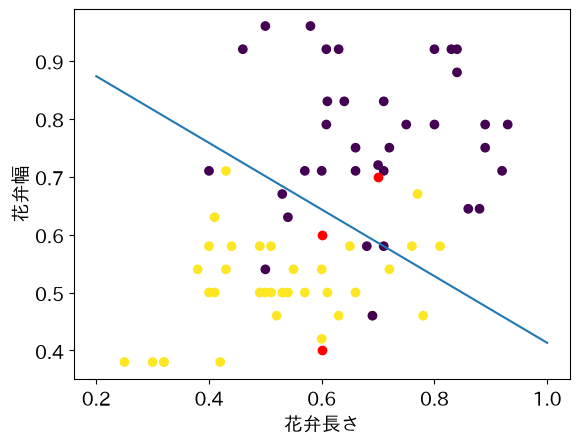

In [ ]:
# モデルの可視化
df = pd.read_csv('iris.csv')
df = df[df['種類'] != 'setosa']
df = df.fillna(df[['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']].mean())
x_cols = ['花弁長さ', '花弁幅']
t_col = ['種類']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=random_seed)
from sklearn.linear_model import LogisticRegression
logistic_regression_model = LogisticRegression(random_state=random_seed)
logistic_regression_model.fit(X=x_train, y=t_train)
a = logistic_regression_model.coef_
b = logistic_regression_model.intercept_
t_c = t_train['種類'] == 'versicolor'
plt.scatter(x_train['花弁長さ'], x_train['花弁幅'], c=t_c)
plt.xlabel('花弁長さ')
plt.ylabel('花弁幅')
x_plot = np.linspace(0.2, 1.0, 100)
y_plot = -(a[0][0] * x_plot + b[0]) / a[0][1]
plt.plot(x_plot, y_plot)
newdata = [[0.6, 0.4], [0.6, 0.6], [0.7, 0.7]]
newdata = pd.DataFrame(newdata, columns=x_cols)
plt.scatter(newdata['花弁長さ'], newdata['花弁幅'], color='red')
plt.show()

# ロジスティック回帰によるデータ分析例：3カテゴリ分類

## 用いるデータと分析の目的
* 引き続きアヤメデータを用いる
* 4つの特徴量（がく片長さ，がく片幅，花弁長さ，花弁幅）から，花の種類（3種類）を予測する
* そのために，3カテゴリ・4次元ロジスティック回帰モデルを用いて分析を行う
* 目的変数と説明変数は以下のとおり
  * 目的変数： 種類
  * 説明変数（4個）：がく片長さ，がく片幅，花弁長さ，花弁幅

## データの前処理
* 欠損値を算術平均に置き換える
* 目的変数と説明変数に分割
* 訓練データ（70％）とテストデータ（30%）に分割

## 一連の分析
* `fit`メソッドを用いて学習
* `predict`メソッドを用いて予測
* 評価（精度とオッズ比の計算）
>* `score`メソッドを用いて精度を計算
>* `exp`関数を用いてオッズ比を計算
* `coef_`属性と`intercept_`属性から回帰係数を確認
>* 3クラスで説明変数が4つなので，回帰係数（パラメータ）は合計15個
  
**［以下のコードの処理内容］**
* 2行目: データをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `fillna`メソッドを使って，欠損値を各特徴量の算術平均にそれぞれ置き換えて変数`df`に代入
* 4～7行目: 説明変数と目的変数に分割し，変数`x`と`t`にそれぞれ代入
* 8～9行目: 説明変数`x`と目的変数`y`を訓練データ（70％）と検証データ（30％）に分割し，`x_train`, `x_test`, `t_train`, `t_test`にそれぞれ代入
* 10～12行目: モデルの学習
* 13～17行目: 予測を行い，予測結果と予測確率を表示
* 18～20行目: 訓練データに対する精度（`score_train`）とテストデータに対する精度（`score_test`）を計算し，小数点以下3桁まで表示
* 21～22行目: `logistic_regression_model`オブジェクトの`coef_`属性と`intercept_`属性からから係数パラメータと定数項を取り出し，変数`a`と`b`にそれぞれ代入
* 23～24行目: `print`関数で項目を表示した後，`np.exp(a)`で係数パラメータ`a`に対するオッズ比を計算し，`print`関数で表示
* 25～27行目: `print`関数で項目を表示した後，`print`関数とf-stringを使って，係数パラメータ`a`（12個）と定数項`b`（3個）を表示

In [19]:
# ロジスティック回帰によるデータ分析例：3カテゴリ分類
df = pd.read_csv('iris.csv')
df = df.fillna(df[['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']].mean())
x_cols = ['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']
t_col = ['種類']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=random_seed)
from sklearn.linear_model import LogisticRegression
logistic_regression_model = LogisticRegression(random_state=random_seed)
logistic_regression_model.fit(X=x_train, y=t_train)
newdata = [[0.5, 0.8, 0.6, 0.6], [0.2, 0.7, 0.2, 0.2], [0.2, 0.7, 0.8, 0.7]]
y_pred = logistic_regression_model.predict(X=newdata)
print(f'予測結果： {y_pred}')
y_pred_proba = logistic_regression_model.predict_proba(X=newdata)
print(f'予測確率：{y_pred_proba[0]}, {y_pred_proba[1]}, {y_pred_proba[2]}')
score_train = logistic_regression_model.score(X=x_train, y=t_train)
score_test = logistic_regression_model.score(X=x_test, y=t_test)
print(f'訓練データの精度={score_train:.3f} / テストデータの精度={score_test:.3f}')
a = logistic_regression_model.coef_
b = logistic_regression_model.intercept_
print('オッズ比：')
print(np.exp(a))
print('係数パラメータ:')
print(a)
print(f'定数項: {b}')

予測結果： ['virginica' 'setosa' 'virginica']
予測確率：[0.177 0.262 0.561], [0.8   0.164 0.036], [0.119 0.235 0.646]
訓練データの精度=0.886 / テストデータの精度=0.800
オッズ比：
[[ 0.222  4.076  0.234  0.052]
 [ 1.347  0.241  0.753  1.185]
 [ 3.339  1.018  5.674 16.155]]
係数パラメータ:
[[-1.503  1.405 -1.452 -2.952]
 [ 0.298 -1.423 -0.284  0.17 ]
 [ 1.206  0.017  1.736  2.782]]
定数項: [ 1.757  0.933 -2.69 ]


# アンサンブル学習

## アンサンブル学習とは
* 複数のモデルを組み合わせてモデルの性能を向上させる学習法
* アンサンブル学習の主な利点
  * 予測精度が向上する
  * 過学習のリスクを軽減する
* アンサンブル学習の基本戦略
  * バギング: ブートストラップサンプリングを用いてパラメータが異なる複数のモデルを学習し，その予測を平均化する
  * ブースティング: モデルを逐次的に改善し，性能のよいモデルを構築する
  * スタッキング: 異なるモデルの予測を新たなデータセットとして使用し，別のモデル（メタモデル）で最終的な予測を行う

## バギング
* 複数のモデル（通常は同じタイプのモデル）を学習
* ブートストラップサンプリングによって抽出されたデータを用いる
  * 元データ（n個）からランダムに1個データを抽出し，元に戻す
  * この操作を n回繰り返し，n個のデータ（ブートストラップサンプル）を得る
  * ブートストラップサンプルには同じデータが含まれることもあるし，元データから選ばれないものもある（このような抽出を復元抽出と呼ぶ）
* 下図はブートストラップサンプリングのイメージ（n=5）

  <img src="./fig/bootstrap_sampling.jpg" width="450">

* 各モデルを異なるブートストラップサンプルに基づいて学習する
* 代表的なバギング手法に「ランダムフォレスト」がある

## ランダムフォレスト
* 複数の分類木，または回帰木を用いるバギング手法（回帰木については次回以降説明する）
* 以降，分類木と回帰木のことを決定木と呼ぶ
* ランダムフォレストにおけるブートストラップサンプリング
  * 決定木ごとに元データ（n個）からランダムにn個抽出したデータを用いる
  * 説明変数の候補の中から，一部をに選ぶ ⇒ 各決定木で用いられる説明変数が異なる
* 下図はブートストラップサンプリングのイメージ（n=4で説明変数候補がA, B, C の3つ）

  <img src="./fig/bootstrap_sampling_random_forests.jpg" width="550">



## ブースティング
* ベースのモデルを決め，そのモデルに対して複数のモデルを逐次的に学習する
* 前のモデルの学習結果を利用して，次のモデルの学習を行う
  * 分類の場合: 前のモデルで誤分類されたデータに対して，次のモデルでは誤分類しないように重点的に学習する
  * 回帰の場合: 前のモデルでの予測誤差に基づいてデータを重み付けし，次のモデルで重みに応じた優先度で学習する
* 代表的なブースティング手法
  * アダブースト（AdaBoost），Xgboost，勾配ブースティング
  * アダブーストが最も基本的な手法

### アダブースト
* 分類と回帰の両方に適用できるが，ここでは分類について考える
* 以下の操作を繰り返す
  * 前のモデルの予測結果から各データの重みを更新する ⇒ 正しく分類できたデータの重みは小さくし，誤分類されたデータの重みは大きくする
  * 更新された重みに基づき，次のモデルを学習する ⇒ 前のモデルで誤分類されたデータを重点的に学習していく（ようなイメージ）
* 各繰り返しにおいて，各モデルの予測性能も計算する
* 繰り返し数の決め方には，様々なアプローチがある（詳細は省略）
  * 単純なアプローチの一つに，学習する前に回数を決めておく方法がある
* 各モデルの予測性能を考慮した多数決で最終的な予測を決定
* 良い予測性能のモデルの結果が重要視されるようにする

### アダブーストの学習イメージ
* 例として，身長，体重，年代から派閥（きのこ派 or たけのこ派）を予測する分類を考える
* 下図は，アダブーストの学習のイメージをつかむための図
* モデル1：1回目の学習で得られたモデル（下図左）
  * 正しく分類できたデータが 1, 4 であった ⇒ 重みを小さくする
  * 誤って分類したデータが 0, 2, 3 であった ⇒ 重みを大きくする
  * 精度は 2 / 5 = 0.4
  * 次の学習では，誤って分類したデータ 0, 2, 3 を重点的に学習する
* モデル2：2回目の学習で得られたモデル（下図中央）
  * 正しく分類できたデータが 0, 2, 4 であった ⇒ 重みを小さくする
  * 誤って分類したデータが 1, 3 であった ⇒ 重みを大きくする
  * 精度は 3 / 5 = 0.6
  * 次の学習では，誤って分類したデータ 1, 3 を重点的に学習する
* モデル3：3回目の学習で得られたモデル（下図右）
  * 正しく分類できたデータが 0, 1, 2, 4 であった
  * 誤って分類したデータが 3 であった
  * 精度は 4 / 5 = 0.8
  * 繰り返しはここまでとする

  <img src="./fig/examples_adaboost.jpg" width="600">


### アダブーストの予測イメージ
* 予測性能（精度）によってモデルの重みをつける ⇒ 精度の高いモデルの重みを大きくする
* 例えば，下図のような重みであったとする
* このとき，各モデルの予測結果とモデルの重みを考慮して多数決をとる

  <img src="./fig/examples_adaboost_predictions.jpg" width="550">

# ランダムフォレストによるデータ分析例

## 用いるデータと分析の目的
* 例として，csvファイル「Survived.csv」を用いる
* このデータは，過去に沈没した客船の乗客に関する情報がまとめられたデータ（客船データと呼ぶ）である
  * 出典: 須藤秋良, 株式会社フレアリンク: スッキリわかるPythonによる機械学習入門, インプレス, 2020

|**列名**| **意味** |
|:--|:--|
|乗客ID| 乗客のID |
|生存| 0: 死亡 / 1: 生存 |
|チケットクラス| チケットの等級（1: 1等級 / 2: 2等級 / 3: 3等級） |
|性別| 乗客の性別（female: 女性 / male: 男性） |
|年齢| 乗客の年齢 |
|同乗1| 同乗した兄弟と配偶者の数 |
|同乗2| 同乗した親と子供の数 |
|チケットID| チケットのID |
|運賃| 乗船運賃 |
|部屋番号| 乗客の部屋番号 |
|港コード| 乗船した港を表すアルファベット |

* 客船データを用いて，「生存」を予測するモデルを作成することを分析の目的とする
* モデルは分類木を基にしたランダムフォレストを用いて作成する

## 実習：一連の分析
* 以下のコードで，データの読み込み，前処理，モデルの学習，予測，及び評価を行う
* ここでは，データの前処理を次の手順で行う（基本的に前回と同様）
  * 「性別」をダミー変数化
  * 「年齢」の欠損値への対処
  * 目的変数と説明変数に分割
  * 訓練データ（80％）とテストデータ（20%）に分割
* 分類を目的としたランダムフォレストによるモデルの学習は，`sklearn`（scikit-learn）の`ensemble`モジュールにおける`RandomForestClassifier`クラスを使う
* 学習の流れ:
  * `RandomForestClassifier`クラスを読み込む（インポートする）
  * インポートの書式: `from sklearn.ensemble import RandomForestClassifier`
  * `RandomForestClassifier`クラスのオブジェクトを生成し，変数に代入する
  * オブジェクト生成の書式: `変数 = RandomForestClassifier(n_estimators=[生成する木の数], random_state=[乱数の種])`
    * ここでは，生成する木の数を 200個とする
  * 不均衡データの場合は，引数に`class_weight='balanced'`を指定することで，不均衡データの影響を取り除くことができる
  * モデルを学習する
  * モデルの学習の書式（これまでのモデルと同様）: `変数.fit(説明変数, 目的変数)`
* 予測は，これまでのモデルと同様に`predict`メソッドを用いる
* 精度の計算は，分類木モデルと同様に`score`メソッドを用いる
* 分類木と同様に，`feature_importances_`属性から特徴量重要度が確認できる

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，csvファイルをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `get_dummies`関数を使って，性別列（`df['性別']`）をダミー変数化し，その結果を変数`dummy`に代入
* 4行目: `concat`関数を使って，2つのDataFrame`df`と`dummy`を結合し，変数`df`に代入
* 5～10行目: 「チケットクラス」と「生存」の値の組み合わせごとに，「年齢」の欠損値を算術平均に置き換える
* 11～14行目: 説明変数と目的変数に分割し，変数`x`と`t`にそれぞれ代入
* 15～16行目: 説明変数`x`と目的変数`y`を訓練データ（80％）とテストデータ（20％）に分割し，`x_train`, `x_test`, `t_train`, `t_test`にそれぞれ代入
* 17行目:  `sklearn` (scikit-learn) の`ensemble`モジュール内にある`RandomForestClassifier`クラスをインポートする
* 18行目: `RandomForestClassifier(n_estimators=200, random_state=random_seed)`で，モデルの学習を行うためのオブジェクトを`RandomForestClassifier`クラスから生成し，変数`random_forest_model`に代入
  * `class_weight='balanced'`で不均衡データの影響を取り除く
  * `n_estimators=200'`で生成する木の数を 200 に設定
  * `random_state=random_seed`で乱数の種を指定する
* 19行目: `fit`メソッドで学習を実行
* 20行目: 新しい2つの説明変数データ（`['チケットクラス', '年齢', '同乗1', '同乗2', '運賃', 'female']`）のリスト`[[3, 27, 1, 0, 8, True], [1, 41, 0, 1, 30, False]]`を変数`newdata`に代入
* 21行目: `predict`メソッドを用いて，特徴量`newdata`に対する予測を行い，その結果（`predict`メソッドの戻り値）を`print`関数とf-stringを使って表示
* 22～23行目: `score`メソッドで，訓練データとテストデータから精度を計算し，変数`score_train`と`score_test`にそれぞれ代入
* 24行目: `print`関数とf-stringを使って，訓練データに対する精度（`score_train`）とテストデータに対する精度（`score_test`）を小数点以下3桁まで表示
  * 「`:.3f`」で，小数点以下3桁まで表示
* 25行目: `display`関数で，`random_forest_model`オブジェクトの`feature_importances_`属性（特徴量重要度）を表示
  *  `DataFrame`関数で，`random_forest_model.feature_importances_`（ndarray）をDataFrameに変換
  *  そのDataFrameの行名（`index`）を説明変数`x`の列名（`x_cols`），列名（`columns`）を「特徴量重要度」とした

**［実行結果］**

  <img src="./fig/exercise_survived_random_forests.jpg" width="300">

In [ ]:
# ランダムフォレストによるデータ分析例
df = pd.read_csv('Survived.csv')








x_cols = ['チケットクラス', '年齢', '同乗1', '同乗2', '運賃', 'female']
t_col = ['生存']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2, random_state=random_seed)


random_forest_model.fit(x_train, t_train)
newdata = [[3, 27, 1, 0, 8, True], [1, 41, 0, 1, 30, False]]
print(f'予測結果： {random_forest_model.predict(X=newdata)}')
score_train = random_forest_model.score(X=x_train, y=t_train)
score_test = random_forest_model.score(X=x_test, y=t_test)
print(f'訓練データの精度={score_train:.3f} / テストデータの精度={score_test:.3f}')
display(pd.DataFrame(random_forest_model.feature_importances_, index=x_cols, columns=['特徴量重要度']))

予測結果： [0 0]
訓練データの精度=0.986 / テストデータの精度=0.866


,特徴量重要度
チケットクラス,0.077
年齢,0.305
同乗1,0.053
同乗2,0.035
運賃,0.286
female,0.244


## 分類木モデルとの比較
* ランダムフォレスト（1つ前のコードで学習したモデル）と分類木モデルを比較する
* ここで，分類木モデルの最大深さは 5 とした

In [6]:
# 分類木モデルとの比較
df = pd.read_csv('Survived.csv')
dummy = pd.get_dummies(df['性別'])
df = pd.concat([df, dummy], axis=1)
df.loc[(df['チケットクラス'] == 1) & (df['生存'] == 0) & (df['年齢'].isnull()), '年齢'] = 43
df.loc[(df['チケットクラス'] == 1) & (df['生存'] == 1) & (df['年齢'].isnull()), '年齢'] = 35
df.loc[(df['チケットクラス'] == 2) & (df['生存'] == 0) & (df['年齢'].isnull()), '年齢'] = 33
df.loc[(df['チケットクラス'] == 2) & (df['生存'] == 1) & (df['年齢'].isnull()), '年齢'] = 25
df.loc[(df['チケットクラス'] == 3) & (df['生存'] == 0) & (df['年齢'].isnull()), '年齢'] = 26
df.loc[(df['チケットクラス'] == 3) & (df['生存'] == 1) & (df['年齢'].isnull()), '年齢'] = 20
x_cols = ['チケットクラス', '年齢', '同乗1', '同乗2', '運賃', 'female']
t_col = ['生存']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2, random_state=random_seed)
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=random_seed)
decision_tree_model.fit(x_train, t_train)
newdata = [[3, 27, 1, 0, 8, True], [1, 41, 0, 1, 30, False]]
print(f'予測結果： {decision_tree_model.predict(X=newdata)}')
score_train = decision_tree_model.score(X=x_train, y=t_train)
score_test = decision_tree_model.score(X=x_test, y=t_test)
print(f'訓練データの精度={score_train:.3f} / テストデータの精度={score_test:.3f}')
display(pd.DataFrame(decision_tree_model.feature_importances_, index=x_cols, columns=['特徴量重要度']))

予測結果： [0 1]
訓練データの精度=0.865 / テストデータの精度=0.860


,特徴量重要度
チケットクラス,0.121
年齢,0.251
同乗1,0.068
同乗2,0.003
運賃,0.051
female,0.506


# アダブーストによるデータ分析例
* 引き続き客船データを用いて，「生存」を予測するモデルを作成する
* モデルは最大深さ5の分類木モデルを基にしたアダブーストを用いて作成する
* 前処理はランダムフォレストによる学習と同じ処理を行う
* アダブーストによる分類モデルの学習は，`sklearn`（scikit-learn）の`ensemble`モジュールにおける`AdaBoostClassifier`クラスを使う
* 学習の流れ:
  * ベースとなるモデルを指定： 今回は最大深さ5の分類木モデルを指定するので，`DecisionTreeClassifier`クラスのオブジェクトを生成する
  * `AdaBoostClassifier`クラスをインポートする
  * インポートの書式: `from sklearn.ensemble import AdaBoostClassifier`
  * `AdaBoostClassifier`クラスのオブジェクトを生成し，変数に代入する
  * オブジェクト生成の書式: `変数 = AdaBoostClassifier(n_estimators=[作成するモデル数], random_state=[乱数の種], estimator=[ベースとなるモデル（オブジェクト）])`
  * モデルを学習する
  * モデルの学習の書式（これまでのモデルと同様）: `変数.fit(説明変数, 目的変数)`

## 実習：一連の分析
* 以下のコードで，データの読み込み，前処理，モデルの学習，予測，及び評価を行う
* 予測は，これまでのモデルと同様に`predict`メソッドを用いる
* 精度の計算は，分類木と同様に`score`メソッドを用いる
* 分類木と同様に，`feature_importances_`属性から特徴量重要度が確認できる

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，csvファイルをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `get_dummies`関数を使って，性別列（`df['性別']`）をダミー変数化し，その結果を変数`dummy`に代入
* 4行目: `concat`関数を使って，2つのDataFrame`df`と`dummy`を結合し，変数`df`に代入
* 5～10行目: 「チケットクラス」と「生存」の値の組み合わせごとに，「年齢」の欠損値を算術平均に置き換える
* 11～14行目: 説明変数と目的変数に分割し，変数`x`と`t`にそれぞれ代入
* 15～16行目: 説明変数`x`と目的変数`y`を訓練データ（80％）とテストデータ（20％）に分割し，`x_train`, `x_test`, `t_train`, `t_test`にそれぞれ代入
* 17～18行目: `DecisionTreeClassifier`クラスから，1つ前のコードと同様のオブジェクトを生成し，変数`base_model`に代入
  * このオブジェクトがベースとなるモデルに対応
* 19行目:  `sklearn` (scikit-learn) の`ensemble`モジュール内にある`AdaBoostClassifier`クラスをインポートする
* 20行目: `AdaBoostClassifier(n_estimators=500, random_state=random_seed, estimator=base_model)`で，モデルの学習を行うためのオブジェクトを`AdaBoostClassifier`クラスから生成し，変数`adaBoost_model`に代入
  * `n_estimators=500'`で作成するモデルの数を 500 に設定
  * `random_state=random_seed`で乱数の種を指定する
* 21行目: `fit`メソッドで学習を実行
* 22行目: 新しい2つの説明変数データ（`['チケットクラス', '年齢', '同乗1', '同乗2', '運賃', 'female']`）のリスト`[[3, 27, 1, 0, 8, True], [1, 41, 0, 1, 30, False]]`を変数`newdata`に代入
* 23行目: `predict`メソッドを用いて，特徴量`newdata`に対する予測を行い，その結果（`predict`メソッドの戻り値）を`print`関数とf-stringを使って表示
* 24～25行目: `score`メソッドで，訓練データとテストデータから精度を計算し，変数`score_train`と`score_test`にそれぞれ代入
* 26行目: `print`関数とf-stringを使って，訓練データに対する精度（`score_train`）とテストデータに対する精度（`score_test`）を小数点以下3桁まで表示
  * 「`:.3f`」で，小数点以下3桁まで表示
* 27行目: `display`関数で，`random_forest_model`オブジェクトの`feature_importances_`属性（特徴量重要度）を表示
  * `DataFrame`関数で，`random_forest_model.feature_importances_`（ndarray）をDataFrameに変換
  * そのDataFrameの行名（`index`）を説明変数`x`の列名（`x_cols`），列名（`columns`）を「特徴量重要度」とした

**［実行結果］**

  <img src="./fig/exercise_survived_adaboost.jpg" width="300">

In [ ]:
# アダブーストによるデータ分析例
df = pd.read_csv('Survived.csv')












from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2, random_state=random_seed)
from sklearn.tree import DecisionTreeClassifier



adaBoost_model.fit(x_train, t_train)
newdata = [[3, 27, 1, 0, 8, True], [1, 41, 0, 1, 30, False]]
print(f'予測結果： {adaBoost_model.predict(X=newdata)}')
score_train = adaBoost_model.score(X=x_train, y=t_train)
score_test = adaBoost_model.score(X=x_test, y=t_test)
print(f'訓練データの精度={score_train:.3f} / テストデータの精度={score_test:.3f}')
display(pd.DataFrame(adaBoost_model.feature_importances_, index=x_cols, columns=['特徴量重要度']))

# 参考文献・資料
* 松尾豊(監修): 東京大学のデータサイエンティスト育成講座, マイナビ出版, 2019
* 伊藤真, Pythonで動かして学ぶ！あたらしい機械学習の教科書　第2版, 翔泳社, 2019